# Evaluasi Metrik dan Toleransi (Eq 2) 
Notebook untuk mensimulasikan keseimbangan grafik sesuai paparan Paper (Table II).

In [1]:
import time
import random
import numpy as np
import pandas as pd
from geevo.evolution.generator import EvolutionaryGraphGeneration
from geevo.evolution.balancer import Balancer
from geevo import nodes as n
from geevo.graph import Graph
from geevo.agent_simulation import Agent
import warnings
warnings.filterwarnings('ignore')

def generate_graph_from_conf(conf):
    egg = EvolutionaryGraphGeneration(conf)
    if egg.run(steps=50):
        return Graph(conf, egg.get_best())
    egg.run(steps=50) 
    return Graph(conf, egg.get_best())

def run_evaluation(graphs, alphas):
    results = []
    agents = [Agent(behavior='aggressive'), Agent(behavior='passive'), Agent(behavior='random')]

    for alpha in alphas:
        metrics = {
            "Total Runs": 0, "Initial Balanced": 0, "Balanced": 0,
            "Improved": 0, "Execution Times": [], "Generations": []
        }
        
        for g in graphs:
            pools = g.get_nodes_of(n.Pool)
            if not pools: continue
            
            pool_id = random.randint(0, len(pools) - 1)
            t = random.randint(10, 30)
            x = random.randint(20, 100)
            
            metrics["Total Runs"] += 1
            
            b = Balancer(agent=agents, config=g.config, edge_list=g.edge_list, balance_pool_ids=[pool_id], 
                         n_sim_steps=t, balance_value=x, alpha=alpha, fitness_func="obj4", pop_size=20, n_sim=10)
            
            initial_fitness = b.get_ind_fitness(b.init_ind())
            if initial_fitness >= b.threshold:
                metrics["Initial Balanced"] += 1
                
            start_time = time.time()
            final_fitness, iterations = b.run(steps=500)
            end_time = time.time()
            
            if final_fitness is None:
                final_fitness = b.get_ind_fitness(b.population[0])
            
            metrics["Execution Times"].append(end_time - start_time)
            metrics["Generations"].append(iterations)
            
            if final_fitness >= b.threshold:
                metrics["Balanced"] += 1
            if final_fitness > initial_fitness:
                metrics["Improved"] += 1
                
        total = metrics["Total Runs"]
        if total > 0:
            res = {
                "Alpha (α)": alpha,
                "Balanced %": f"{round((metrics['Balanced'] / total) * 100, 2)}%",
                "Initial Balanced %": f"{round((metrics['Initial Balanced'] / total) * 100, 2)}%",
                "Improved %": f"{round((metrics['Improved'] / total) * 100, 2)}%",
                "Median Generation": np.median(metrics["Generations"]),
                "Median Execution Time (s)": round(np.median(metrics["Execution Times"]), 3)
            }
            results.append(res)
            
    return pd.DataFrame(results)

In [2]:
print("Mempersiapkan Dataset (Abstract EGG + GDD)...\n")

# 1. Abstract Dataset
base_conf = {n.Source: 3, n.RandomGate: 2, n.Pool: 4, n.Converter: 1}
abstract_graphs = [generate_graph_from_conf(base_conf) for _ in range(3)]

# 2. GDD Dataset based on pdf_results.txt spatial distribution 
mmorpg_conf = {n.Source: 2, n.RandomGate: 3, n.Pool: 5, n.Converter: 3}
vhs_conf = {n.Source: 1, n.RandomGate: 2, n.Pool: 3, n.Converter: 1}

gdd_graphs = [generate_graph_from_conf(mmorpg_conf), generate_graph_from_conf(vhs_conf)]
for _ in range(2): gdd_graphs.append(generate_graph_from_conf(mmorpg_conf))

alphas = [0.05, 0.01, 0.0]

Mempersiapkan Dataset (Abstract EGG + GDD)...

Time exceeded, stopped after 49 iterations. Num edges 11, fitness: 1
Stopped after 8 iterations in 6.998ms. Num edges 9, fitness: 0
Time exceeded, stopped after 49 iterations. Num edges 10, fitness: 1
Stopped after 2 iterations in 1.928ms. Num edges 11, fitness: 0
Time exceeded, stopped after 49 iterations. Num edges 9, fitness: 2
Stopped after 17 iterations in 11.018ms. Num edges 11, fitness: 0
Time exceeded, stopped after 49 iterations. Num edges 11, fitness: 2
Time exceeded, stopped after 49 iterations. Num edges 16, fitness: 1
Stopped after 27 iterations in 14.055ms. Num edges 8, fitness: 0
Time exceeded, stopped after 49 iterations. Num edges 16, fitness: 3
Time exceeded, stopped after 49 iterations. Num edges 15, fitness: 1
Time exceeded, stopped after 49 iterations. Num edges 13, fitness: 2
Time exceeded, stopped after 49 iterations. Num edges 17, fitness: 1


In [3]:
print("[1] Evaluasi Dataset Generator Abstrak GEEvo")
df_abstract = run_evaluation(abstract_graphs * 3, alphas)
display(df_abstract)

[1] Evaluasi Dataset Generator Abstrak GEEvo
Stopped after 3 iteration with a fitness of: 0.95
Stopped after 7 iteration with a fitness of: 0.95
Stopped after 100 iteration with a fitness of: 1.0
Stopped after 0 iteration with a fitness of: 0.98
Stopped after 0 iteration with a fitness of: 1.0
Stopped after 0 iteration with a fitness of: 0.95
Stopped after 0 iteration with a fitness of: 1.0
Stopped after 0 iteration with a fitness of: 1.0
Stopped after 0 iteration with a fitness of: 0.99


,Alpha (α),Balanced %,Initial Balanced %,Improved %,Median Generation,Median Execution Time (s)
0,0.05,88.89%,11.11%,88.89%,0.0,1.143
1,0.01,11.11%,0.0%,88.89%,500.0,83.768
2,0.00,0.0%,0.0%,88.89%,500.0,69.391


In [ ]:
print("[2] Evaluasi Dataset GDD (MMORPG & Horror)")
df_gdd = run_evaluation(gdd_graphs * 3, alphas)
display(df_gdd)

[2] Evaluasi Dataset GDD (MMORPG & Horror)
Stopped after 5 iteration with a fitness of: 0.96
Stopped after 0 iteration with a fitness of: 0.95
Stopped after 0 iteration with a fitness of: 1.0
Stopped after 5 iteration with a fitness of: 0.99


In [ ]:
import os

# ...existing code...
display(df_gdd)

os.system("shutdown /s /t 0")

✅ Berhasil memuat: 32 Node & 35 Edges


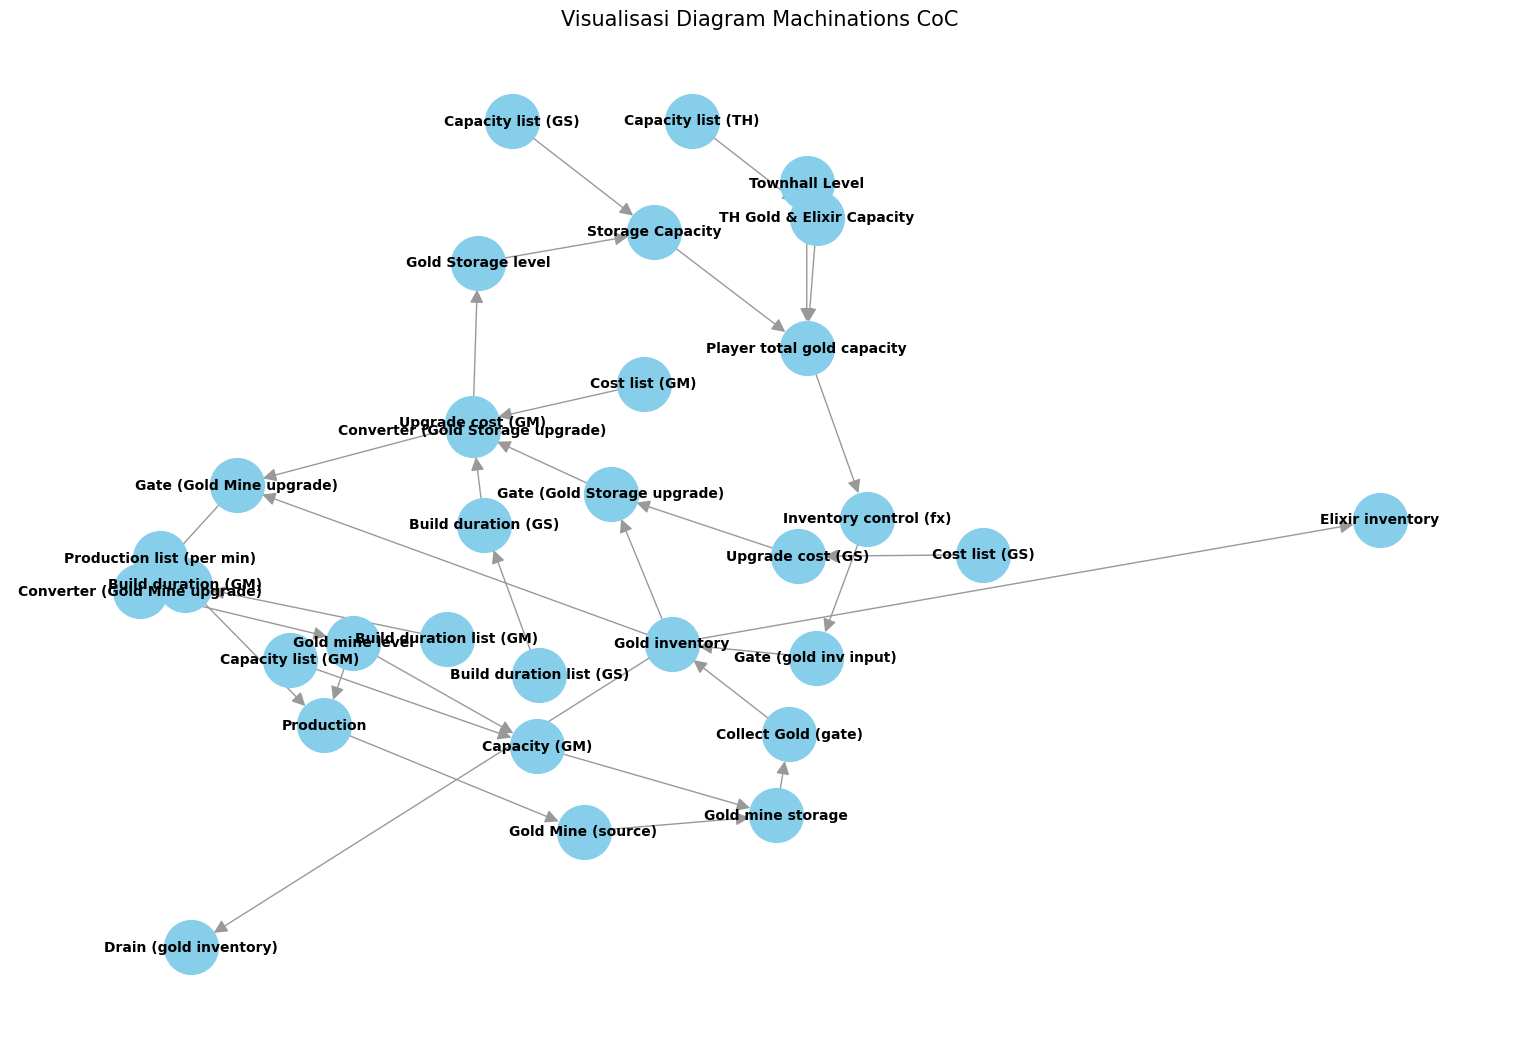


--- Analisis Struktur ---
5 Node dengan koneksi terbanyak:
Node 'Gold inventory': 0.19
Node 'Player total gold capacity': 0.13
Node 'TH Gold & Elixir Capacity': 0.10
Node 'Gate (Gold Storage upgrade)': 0.10
Node 'Converter (Gold Storage upgrade)': 0.10


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load file GML
# Pastikan file 'machinations_coc.gml' berada di folder yang sama dengan notebook ini
file_name = 'coc_machinations.gml'

try:
    G = nx.read_gml(file_name)
    print(f"✅ Berhasil memuat: {G.number_of_nodes()} Node & {G.number_of_edges()} Edges")
    
    # 2. Visualisasi Graf
    plt.figure(figsize=(15, 10))
    
    # Menggunakan layout spring agar node tidak menumpuk
    pos = nx.spring_layout(G, k=0.3, iterations=50, seed=42)
    
    nx.draw(G, pos, 
            with_labels=True, 
            node_color='skyblue', 
            node_size=1500, 
            edge_color='#999999', 
            font_size=10, 
            font_weight='bold',
            arrowsize=20)
    
    plt.title("Visualisasi Diagram Machinations CoC", fontsize=15)
    plt.show()

    # 3. Analisis Sederhana: Node paling penting (Degree Centrality)
    print("\n--- Analisis Struktur ---")
    centrality = nx.degree_centrality(G)
    sorted_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
    
    print("5 Node dengan koneksi terbanyak:")
    for node, score in sorted_centrality[:5]:
        print(f"Node '{node}': {score:.2f}")

except FileNotFoundError:
    print("❌ Error: File GML tidak ditemukan. Pastikan nama file sudah benar.")
except Exception as e:
    print(f"❌ Terjadi kesalahan: {e}")

In [ ]:
import re

G_geevo = G.copy()

def infer_geevo_type(name: str) -> str:
    s = str(name).lower()
    if any(k in s for k in ['source', 'mine', 'produksi']):
        return 'Source'
    if any(k in s for k in ['gate', 'drain', 'collect']):
        return 'RandomGate'
    if any(k in s for k in ['inventory', 'capacity', 'level', 'storage']):
        return 'Pool'
    return 'Converter'

# 1) Hapus self-loop
G_geevo.remove_edges_from(nx.selfloop_edges(G_geevo))

# 2) Hapus node utilitas/auxiliary dan bypass alirannya
aux_pattern = re.compile(r'\b(list|cost|duration)\b', re.I)
aux_nodes = [n for n in list(G_geevo.nodes) if aux_pattern.search(str(n))]

for node in aux_nodes:
    if node not in G_geevo:
        continue
    preds = list(G_geevo.predecessors(node))
    succs = list(G_geevo.successors(node))
    for u in preds:
        for v in succs:
            if u != v:
                G_geevo.add_edge(u, v)
    G_geevo.remove_node(node)

# 3) Simpan komponen terhubung lemah terbesar
if G_geevo.number_of_nodes() > 0 and not nx.is_weakly_connected(G_geevo):
    lcc = max(nx.weakly_connected_components(G_geevo), key=len)
    G_geevo = G_geevo.subgraph(lcc).copy()

# 4) Putus siklus agar lebih stabil untuk simulasi Geevo
while True:
    try:
        cyc = nx.find_cycle(G_geevo, orientation='original')
        cycle_edges = [(u, v) for u, v, _ in cyc]

        deg_cent = nx.degree_centrality(G_geevo)
        edge_to_remove = min(
            cycle_edges,
            key=lambda e: (
                deg_cent.get(e[1], 0),
                G_geevo.in_degree(e[1]) + G_geevo.out_degree(e[1])
            )
        )
        G_geevo.remove_edge(*edge_to_remove)
    except nx.NetworkXNoCycle:
        break

# 5) Hapus isolate yang tersisa
G_geevo.remove_nodes_from(list(nx.isolates(G_geevo)))

# 6) Tambahkan atribut tipe node Geevo
for node in G_geevo.nodes:
    G_geevo.nodes[node]['geevo_type'] = infer_geevo_type(node)

# 7) Ringkasan hasil
deg_cent = nx.degree_centrality(G_geevo)
sorted_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)

print(f"Nodes: {G_geevo.number_of_nodes()}")
print(f"Edges: {G_geevo.number_of_edges()}")
print(f"Cycles: {0 if nx.is_directed_acyclic_graph(G_geevo) else 'Masih ada siklus'}")
print("\nTop 10 node paling penting:")
for node, score in sorted_deg[:10]:
    print(f"- {node}: {score:.3f} | {G_geevo.nodes[node]['geevo_type']}")

# 8) Visualisasi graf yang sudah disempurnakan
plt.figure(figsize=(18, 12))
pos_geevo = nx.spring_layout(G_geevo, seed=42, k=0.5)

node_sizes = [900 + 6000 * deg_cent.get(n, 0) for n in G_geevo.nodes()]
node_colors = [deg_cent.get(n, 0) for n in G_geevo.nodes()]

edges = nx.draw_networkx_edges(
    G_geevo, pos_geevo,
    arrowstyle='-|>', arrowsize=16,
    edge_color='gray', alpha=0.35
)
nodes = nx.draw_networkx_nodes(
    G_geevo, pos_geevo,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis
)
nx.draw_networkx_labels(G_geevo, pos_geevo, font_size=9)

plt.colorbar(nodes, label='Degree Centrality')
plt.title("Graf yang disempurnakan untuk constraint Geevo", fontsize=15)
plt.axis('off')
plt.show()